In [29]:

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)


import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))


/kaggle/input/airline-delay/Airline_Delay_Cause.csv


In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, mean_absolute_error, mean_squared_error

import shap

import warnings
warnings.filterwarnings("ignore")
sns.set(style="whitegrid")

# ****Loading the Dataset****

In [35]:
df = pd.read_csv("/kaggle/input/airline-delay/Airline_Delay_Cause.csv")  
df.head()

,year,month,carrier,carrier_name,airport,airport_name,arr_flights,arr_del15,carrier_ct,weather_ct,...,security_ct,late_aircraft_ct,arr_cancelled,arr_diverted,arr_delay,carrier_delay,weather_delay,nas_delay,security_delay,late_aircraft_delay
0,2023,12,9E,Endeavor Air Inc.,ABE,"Allentown/Bethlehem/Easton, PA: Lehigh Valley ...",72.0,5.0,2.46,1.00,...,0.0,0.81,0.0,0.0,672.0,61.0,574.0,20.0,0.0,17.0
1,2023,12,9E,Endeavor Air Inc.,AEX,"Alexandria, LA: Alexandria International",62.0,7.0,4.25,0.00,...,0.0,1.75,0.0,0.0,348.0,252.0,0.0,33.0,0.0,63.0
2,2023,12,9E,Endeavor Air Inc.,AGS,"Augusta, GA: Augusta Regional at Bush Field",95.0,10.0,5.94,0.00,...,0.0,3.00,0.0,0.0,859.0,536.0,0.0,47.0,0.0,276.0
3,2023,12,9E,Endeavor Air Inc.,ALB,"Albany, NY: Albany International",23.0,2.0,0.56,0.00,...,0.0,1.44,1.0,0.0,75.0,9.0,0.0,0.0,0.0,66.0
4,2023,12,9E,Endeavor Air Inc.,ATL,"Atlanta, GA: Hartsfield-Jackson Atlanta Intern...",2111.0,256.0,76.88,8.75,...,0.0,117.94,1.0,0.0,21424.0,8906.0,732.0,1487.0,0.0,10299.0


In [32]:
df.sample(5)

,year,month,carrier,carrier_name,airport,airport_name,arr_flights,arr_del15,carrier_ct,weather_ct,...,security_ct,late_aircraft_ct,arr_cancelled,arr_diverted,arr_delay,carrier_delay,weather_delay,nas_delay,security_delay,late_aircraft_delay
96368,2019,10,UA,United Air Lines Network,CHS,"Charleston, SC: Charleston AFB/International",138.0,19.0,6.10,0.44,...,0.0,6.27,0.0,0.0,1210.0,522.0,8.0,203.0,0.0,477.0
175003,2015,4,DL,Delta Air Lines Inc.,LIT,"Little Rock, AR: Bill and Hillary Clinton Nat ...",170.0,17.0,5.45,1.91,...,0.0,4.67,0.0,0.0,818.0,197.0,107.0,201.0,0.0,313.0
13521,2023,5,C5,CommuteAir LLC dba CommuteAir,ALB,"Albany, NY: Albany International",93.0,11.0,4.78,0.00,...,0.0,3.72,1.0,0.0,848.0,324.0,0.0,128.0,0.0,396.0
121575,2018,10,NK,Spirit Airlines,BQN,"Aguadilla, PR: Rafael Hernandez",59.0,6.0,4.60,0.00,...,0.0,1.11,0.0,0.0,706.0,194.0,0.0,10.0,0.0,502.0
132703,2018,5,YX,Republic Airline,ALB,"Albany, NY: Albany International",188.0,24.0,4.12,1.00,...,0.0,16.62,8.0,1.0,1555.0,130.0,40.0,127.0,0.0,1258.0


In [33]:
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 179338 entries, 0 to 179337
Data columns (total 21 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   year                 179338 non-null  int64  
 1   month                179338 non-null  int64  
 2   carrier              179338 non-null  object 
 3   carrier_name         179338 non-null  object 
 4   airport              179338 non-null  object 
 5   airport_name         179338 non-null  object 
 6   arr_flights          178997 non-null  float64
 7   arr_del15            178747 non-null  float64
 8   carrier_ct           178997 non-null  float64
 9   weather_ct           178997 non-null  float64
 10  nas_ct               178997 non-null  float64
 11  security_ct          178997 non-null  float64
 12  late_aircraft_ct     178997 non-null  float64
 13  arr_cancelled        178997 non-null  float64
 14  arr_diverted         178997 non-null  float64
 15  arr_delay        

year                     0
month                    0
carrier                  0
carrier_name             0
airport                  0
airport_name             0
arr_flights            341
arr_del15              591
carrier_ct             341
weather_ct             341
nas_ct                 341
security_ct            341
late_aircraft_ct       341
arr_cancelled          341
arr_diverted           341
arr_delay              341
carrier_delay          341
weather_delay          341
nas_delay              341
security_delay         341
late_aircraft_delay    341
dtype: int64

In [34]:
print(df.size) #very big data(can ignore some of missing values)
print(df.shape[0]) #rows
print(df.shape[1]) #cols

3766098
179338
21


In [35]:
df.head()

,year,month,carrier,carrier_name,airport,airport_name,arr_flights,arr_del15,carrier_ct,weather_ct,...,security_ct,late_aircraft_ct,arr_cancelled,arr_diverted,arr_delay,carrier_delay,weather_delay,nas_delay,security_delay,late_aircraft_delay
0,2023,12,9E,Endeavor Air Inc.,ABE,"Allentown/Bethlehem/Easton, PA: Lehigh Valley ...",72.0,5.0,2.46,1.00,...,0.0,0.81,0.0,0.0,672.0,61.0,574.0,20.0,0.0,17.0
1,2023,12,9E,Endeavor Air Inc.,AEX,"Alexandria, LA: Alexandria International",62.0,7.0,4.25,0.00,...,0.0,1.75,0.0,0.0,348.0,252.0,0.0,33.0,0.0,63.0
2,2023,12,9E,Endeavor Air Inc.,AGS,"Augusta, GA: Augusta Regional at Bush Field",95.0,10.0,5.94,0.00,...,0.0,3.00,0.0,0.0,859.0,536.0,0.0,47.0,0.0,276.0
3,2023,12,9E,Endeavor Air Inc.,ALB,"Albany, NY: Albany International",23.0,2.0,0.56,0.00,...,0.0,1.44,1.0,0.0,75.0,9.0,0.0,0.0,0.0,66.0
4,2023,12,9E,Endeavor Air Inc.,ATL,"Atlanta, GA: Hartsfield-Jackson Atlanta Intern...",2111.0,256.0,76.88,8.75,...,0.0,117.94,1.0,0.0,21424.0,8906.0,732.0,1487.0,0.0,10299.0


In [36]:

df.dropna(subset=['arr_delay', 'arr_del15', 'carrier', 'airport',    'carrier_delay', 'weather_delay', 'nas_delay',
    'security_delay', 'late_aircraft_delay'], inplace=True)

df['month'] = df['month'].astype(int)
df['arr_del15'] = df['arr_del15'].astype(int)  # Classification target

In [37]:
df.isnull().sum()

year                   0
month                  0
carrier                0
carrier_name           0
airport                0
airport_name           0
arr_flights            0
arr_del15              0
carrier_ct             0
weather_ct             0
nas_ct                 0
security_ct            0
late_aircraft_ct       0
arr_cancelled          0
arr_diverted           0
arr_delay              0
carrier_delay          0
weather_delay          0
nas_delay              0
security_delay         0
late_aircraft_delay    0
dtype: int64

In [38]:
print(df.size) #very big data(can ignore some of missing values)
print(df.shape[0]) #rows // we loss
print(df.shape[1]) #cols

3753687
178747
21


# EDA Analysis

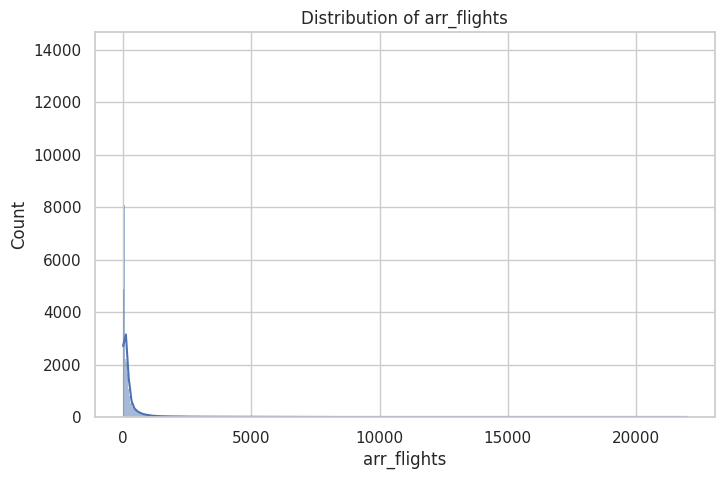

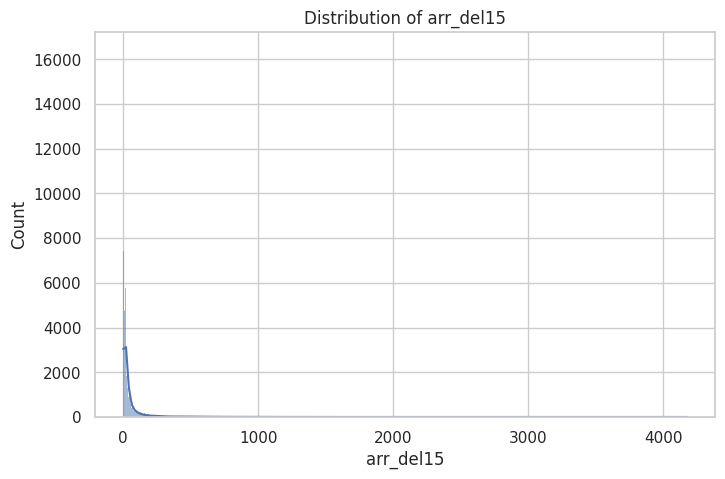

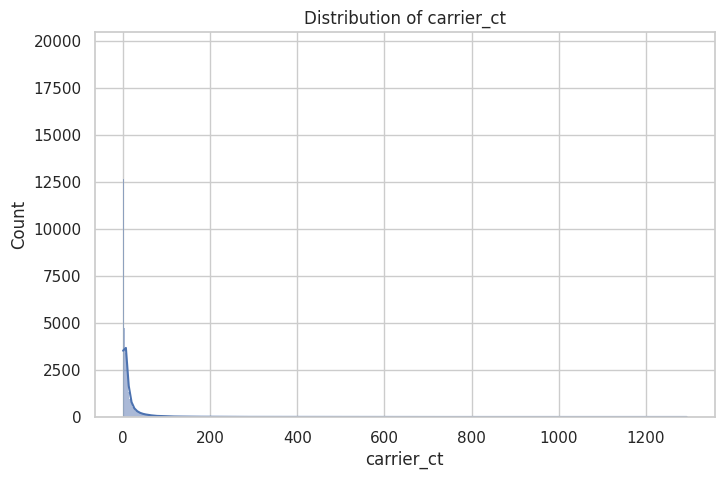

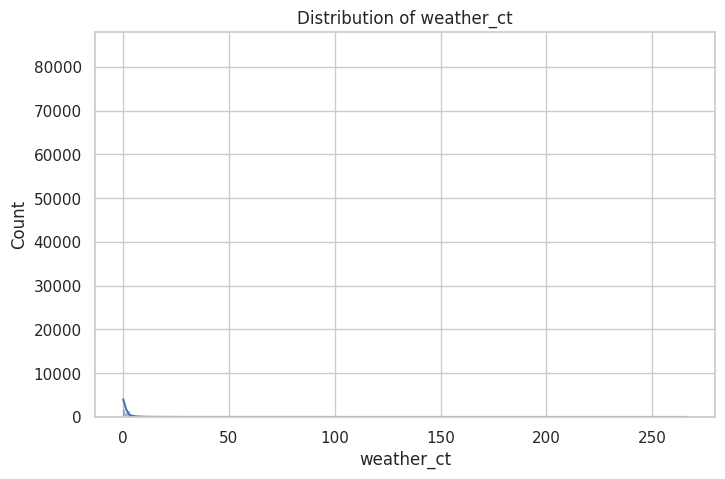

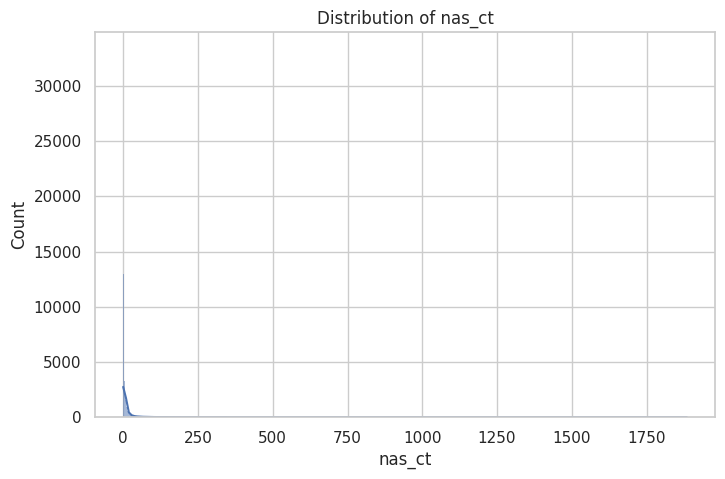

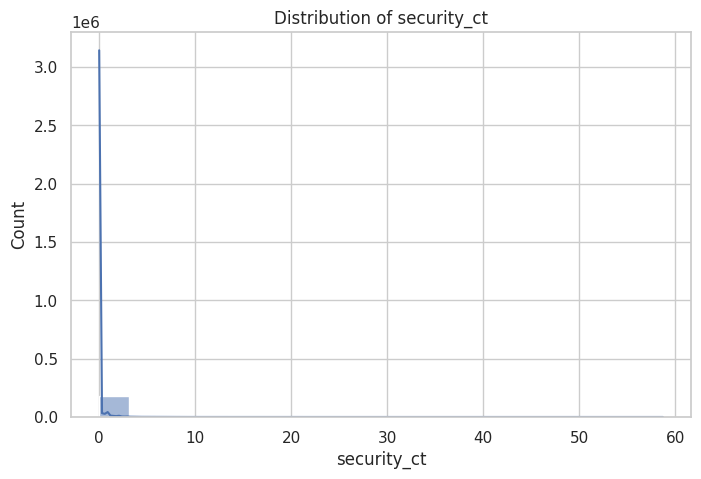

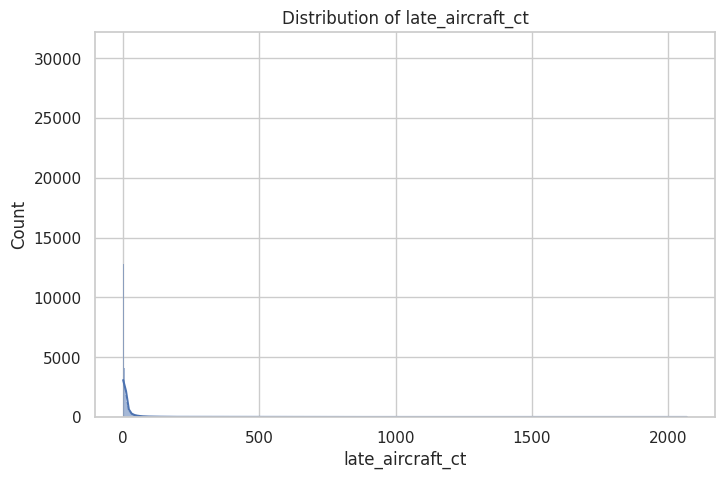

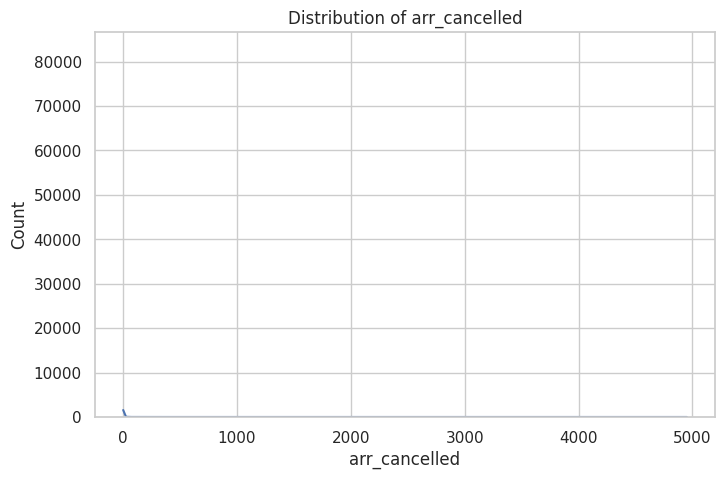

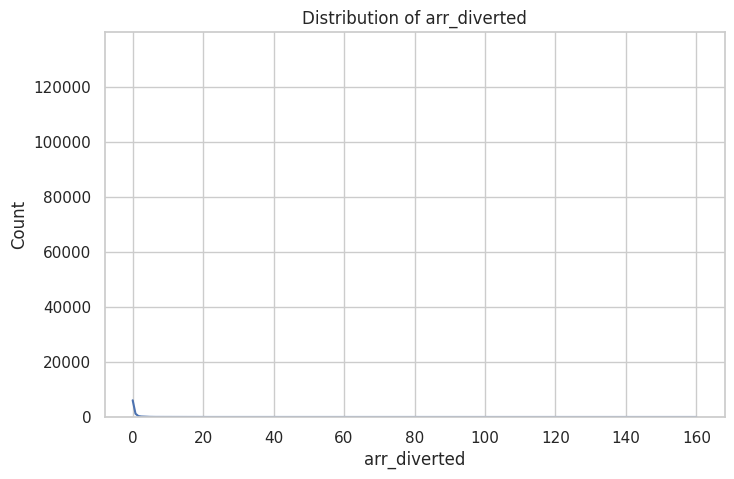

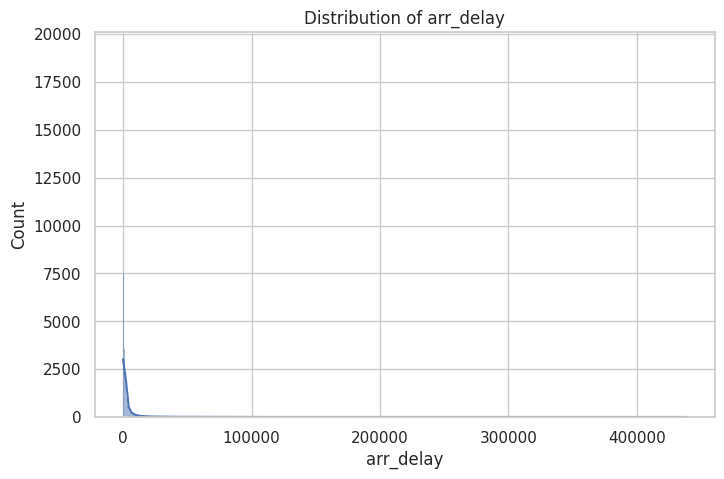

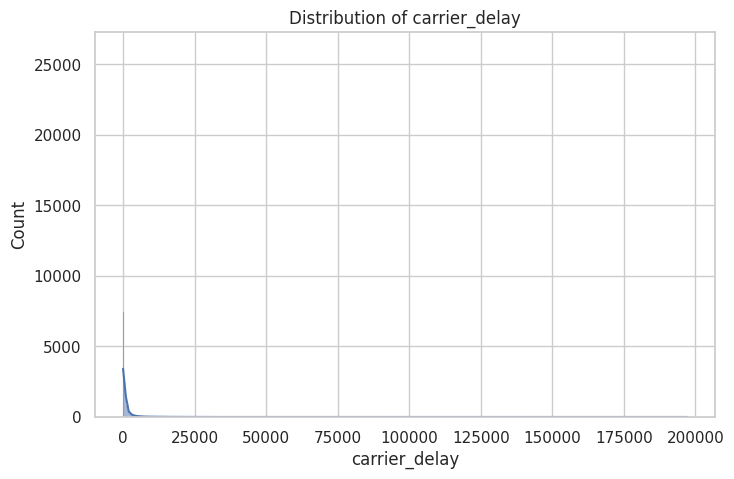

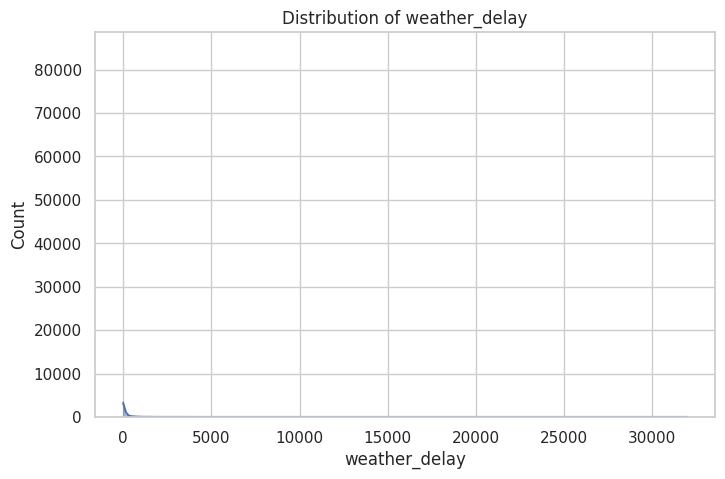

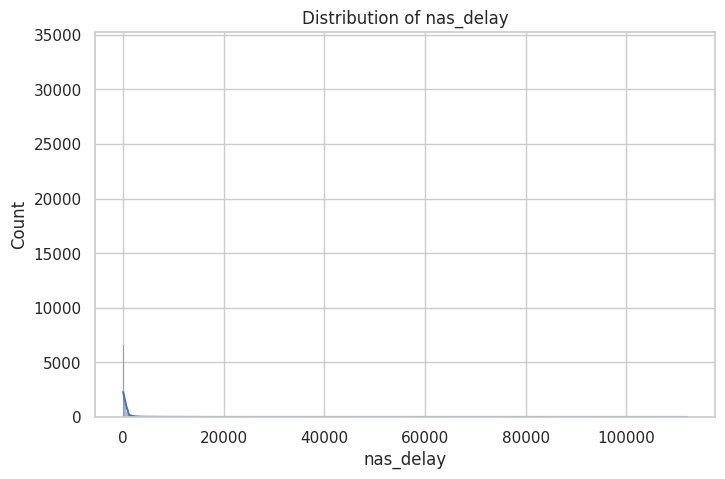

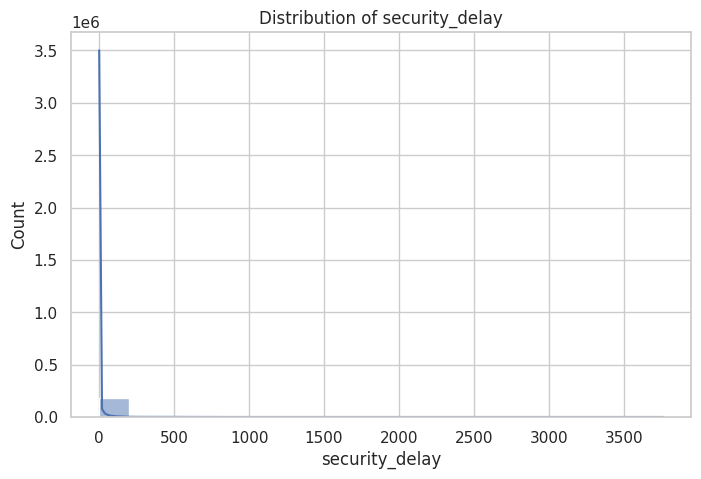

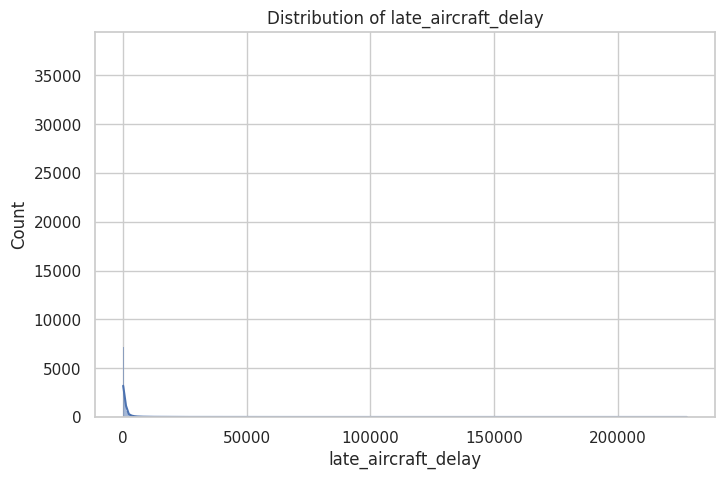

In [32]:
numeric_features = ['arr_flights', 'arr_del15', 'carrier_ct', 'weather_ct', 'nas_ct',
                    'security_ct', 'late_aircraft_ct', 'arr_cancelled', 'arr_diverted',
                    'arr_delay', 'carrier_delay', 'weather_delay', 'nas_delay',
                    'security_delay', 'late_aircraft_delay']

for feature in numeric_features:
    plt.figure(figsize=(8, 5))
    sns.histplot(df[feature], kde=True)
    plt.title(f'Distribution of {feature}')
    plt.show()

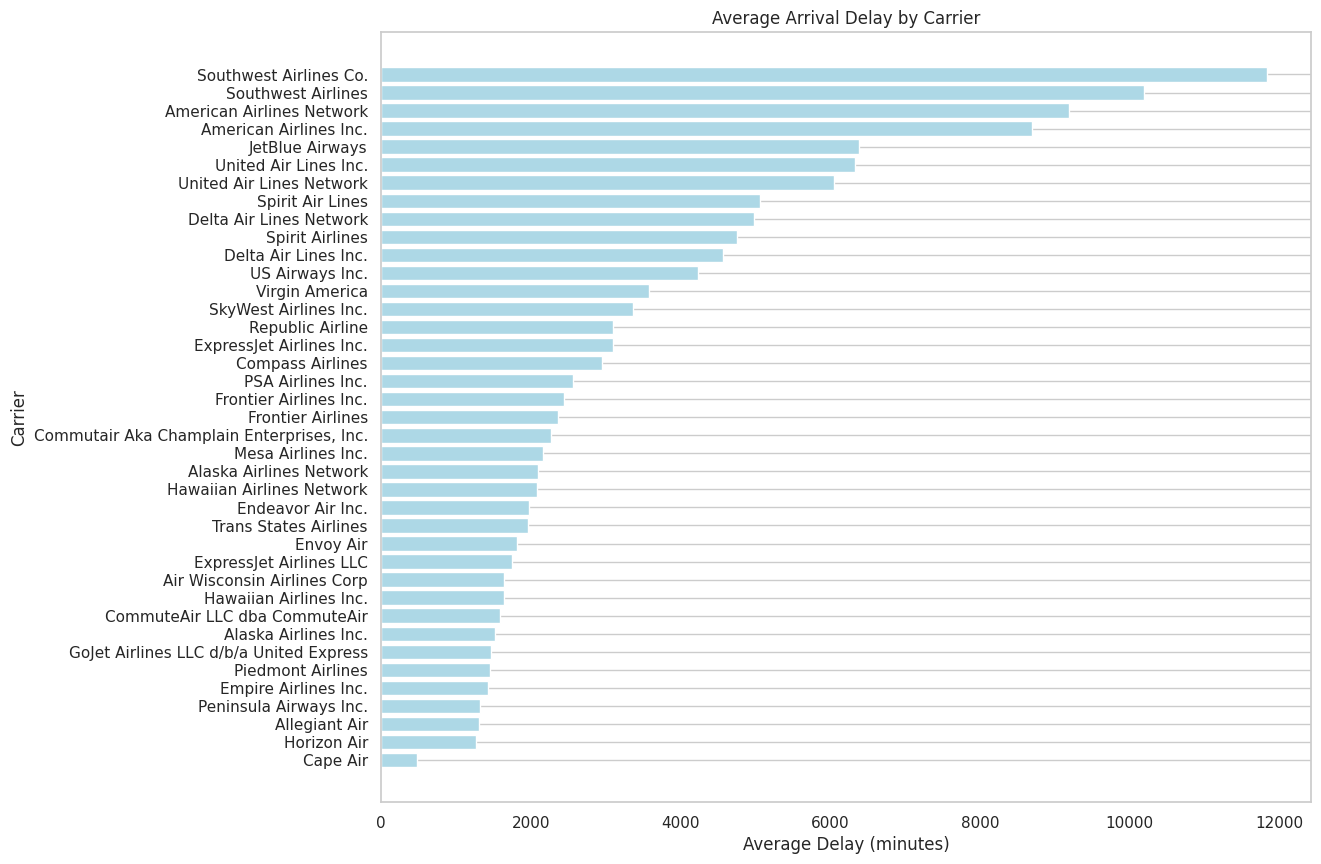

In [38]:
average_delay_per_carrier = df.groupby('carrier_name')['arr_delay'].mean().sort_values().reset_index()

plt.figure(figsize=(12, 10))
plt.barh(average_delay_per_carrier['carrier_name'], average_delay_per_carrier['arr_delay'], color='lightblue')
plt.title('Average Arrival Delay by Carrier')
plt.xlabel('Average Delay (minutes)')
plt.ylabel('Carrier')
plt.grid(axis='x')
plt.show()

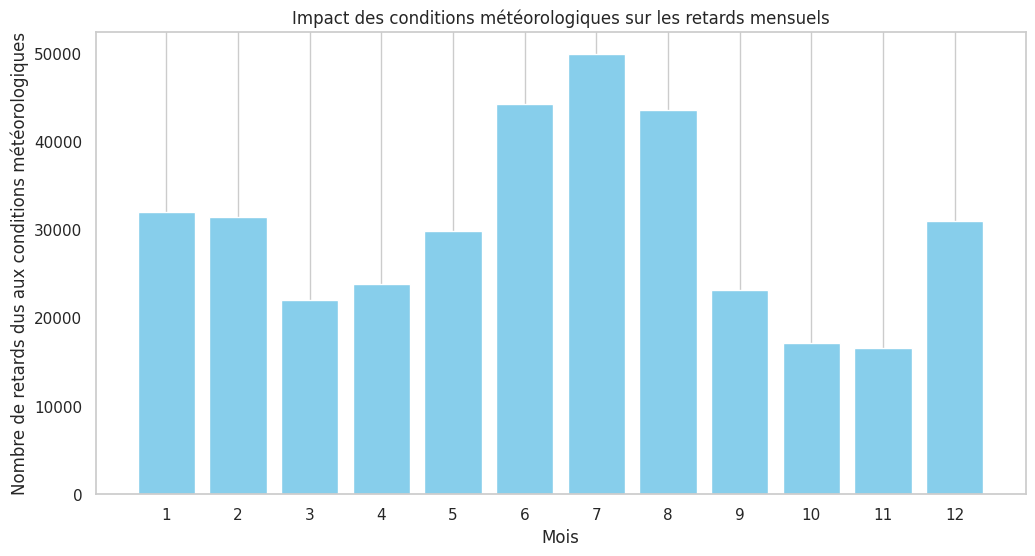

In [39]:
weather_impact = df.groupby(['month'])['weather_ct'].sum().reset_index()
plt.figure(figsize=(12, 6))
plt.bar(weather_impact['month'], weather_impact['weather_ct'], color='skyblue')
plt.title("Impact des conditions météorologiques sur les retards mensuels")
plt.xlabel("Mois")
plt.ylabel("Nombre de retards dus aux conditions météorologiques")
plt.xticks(range(1, 13))
plt.grid(axis='y')
plt.show()

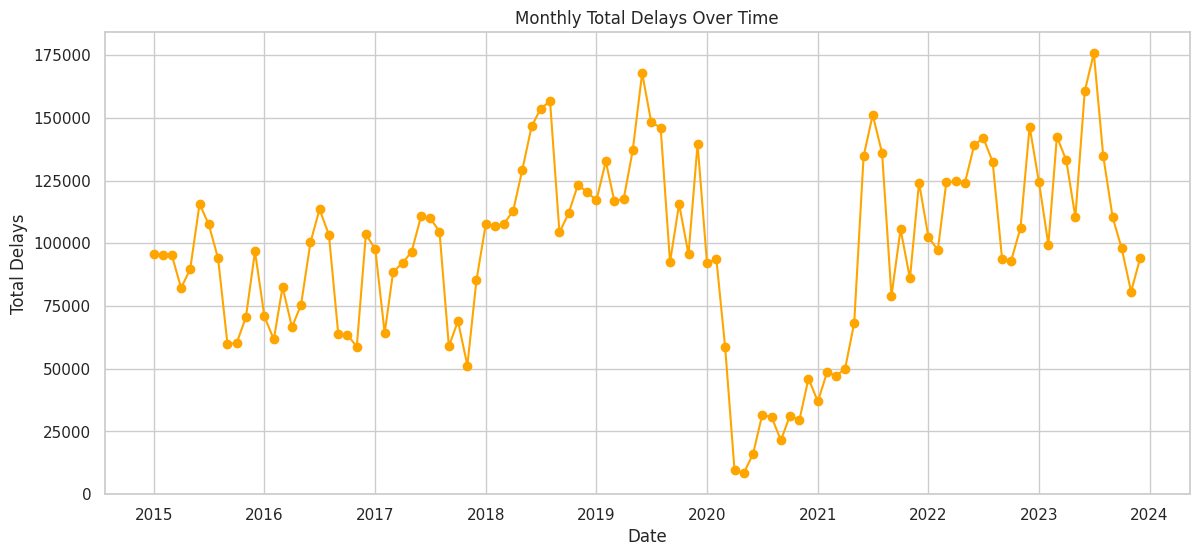

In [40]:
def plot_monthly_trend(column, title, ylabel):
    trend_data = df.groupby(['year', 'month'])[column].sum().reset_index()
    trend_data['date'] = pd.to_datetime(trend_data[['year', 'month']].assign(day=1))#
    plt.figure(figsize=(14, 6))
    plt.plot(trend_data['date'], trend_data[column], marker='o', color='orange')
    plt.title(title)
    plt.xlabel('Date')
    plt.ylabel(ylabel)
    plt.grid(True)
    plt.show()
    
plot_monthly_trend('arr_del15', 'Monthly Total Delays Over Time', 'Total Delays')

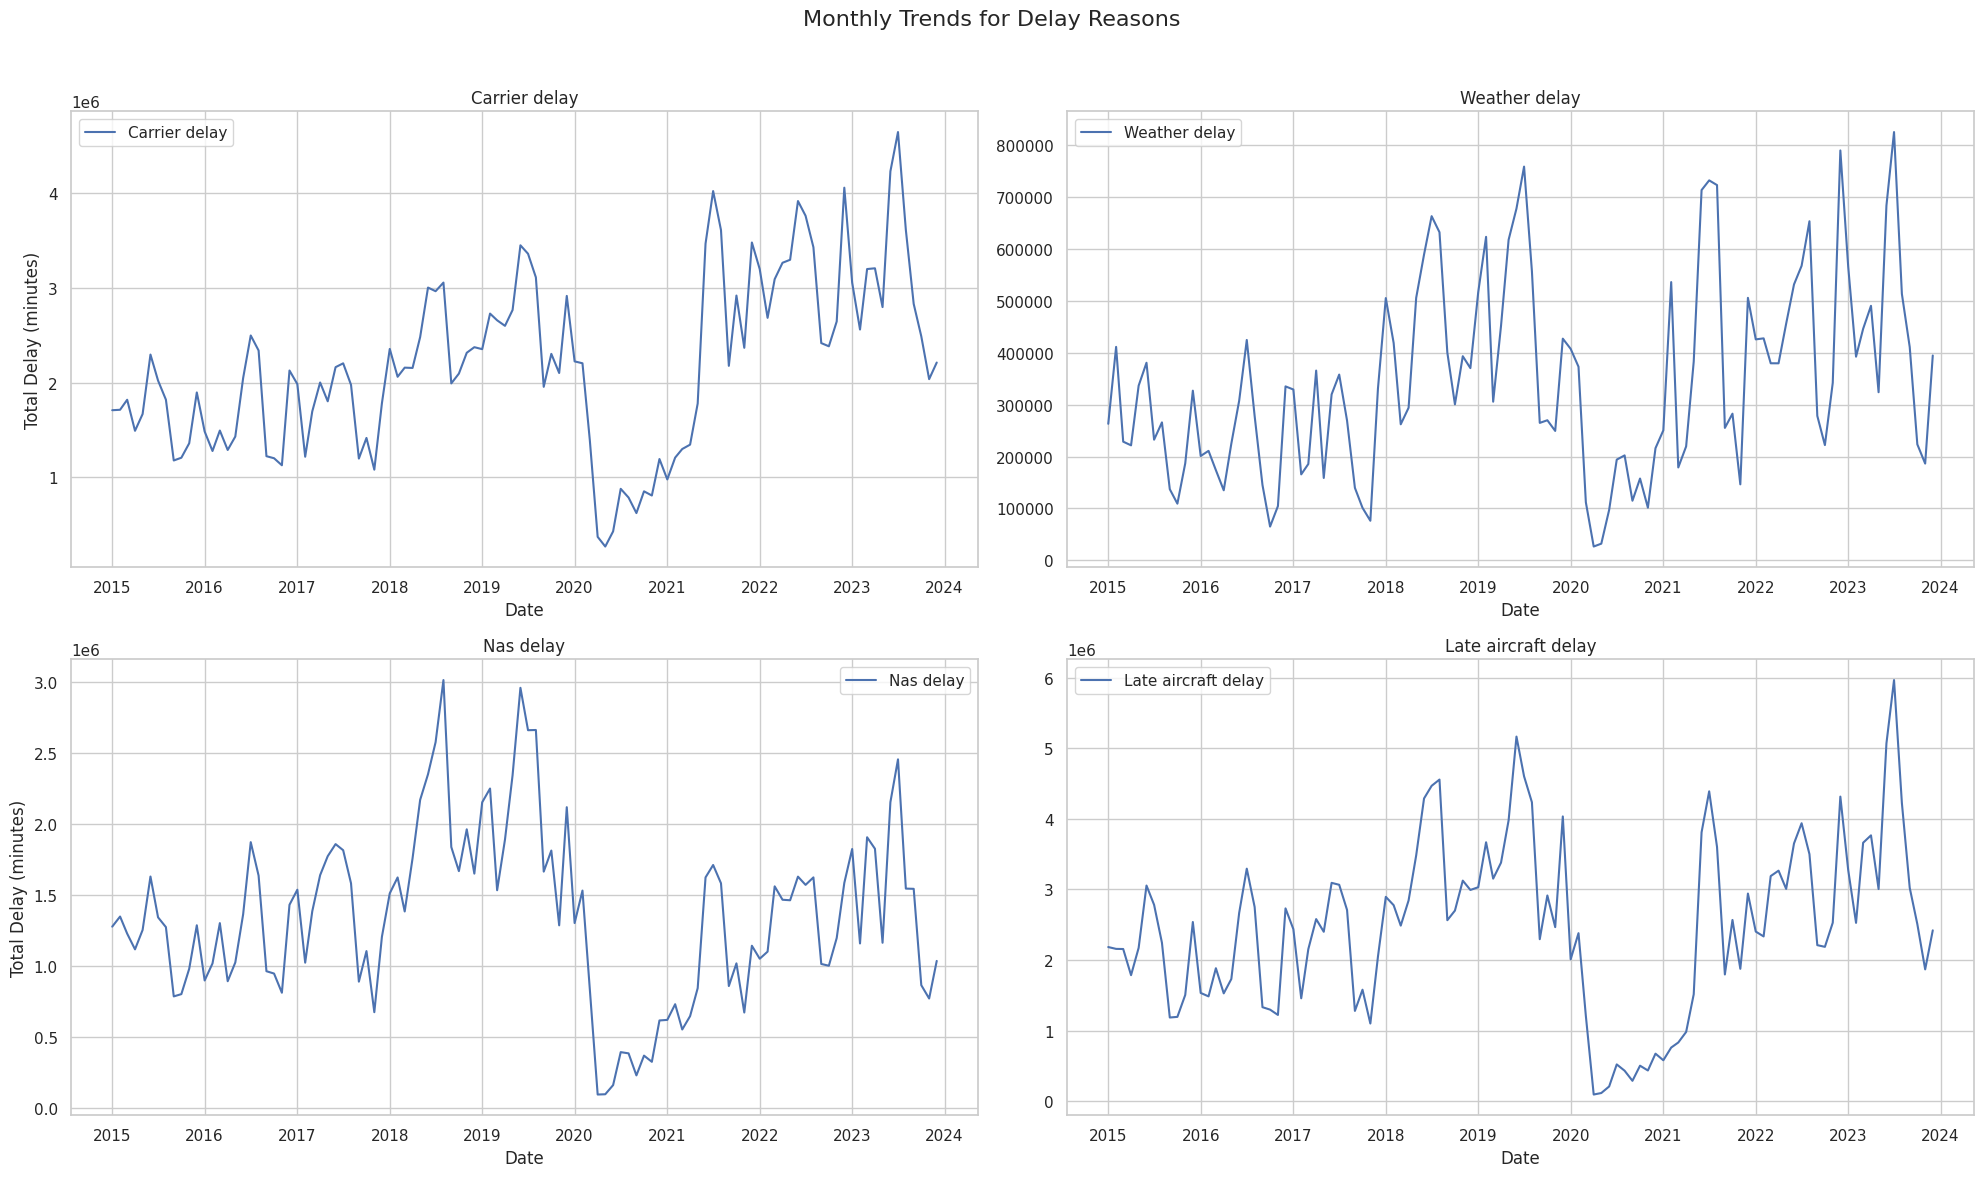

In [41]:
delay_reasons = ['carrier_delay', 'weather_delay', 'nas_delay', 'late_aircraft_delay']


def plot_monthly_trend(column, title, ylabel):
    trend_data = df.groupby(['year', 'month'])[column].sum().reset_index()
    trend_data['date'] = pd.to_datetime(trend_data[['year', 'month']].assign(day=1))
    plt.plot(trend_data['date'], trend_data[column], marker='o', label=title)

fig, axes = plt.subplots(2, 2, figsize=(20, 12))
fig.suptitle('Monthly Trends for Delay Reasons', fontsize=16)

for i, reason in enumerate(delay_reasons[:4]):  # Afficher uniquement 4 raisons sur 2x2
    ax = axes[i // 2, i % 2]
    trend_data = df.groupby(['year', 'month'])[reason].sum().reset_index()
    trend_data['date'] = pd.to_datetime(trend_data[['year', 'month']].assign(day=1))
    ax.plot(trend_data['date'], trend_data[reason], label=reason.replace("_", " ").capitalize())
    ax.set_title(f'{reason.replace("_", " ").capitalize()}')
    ax.set_xlabel('Date')
    if i % 2 == 0:
        ax.set_ylabel('Total Delay (minutes)')
    ax.legend()
    ax.grid(True)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

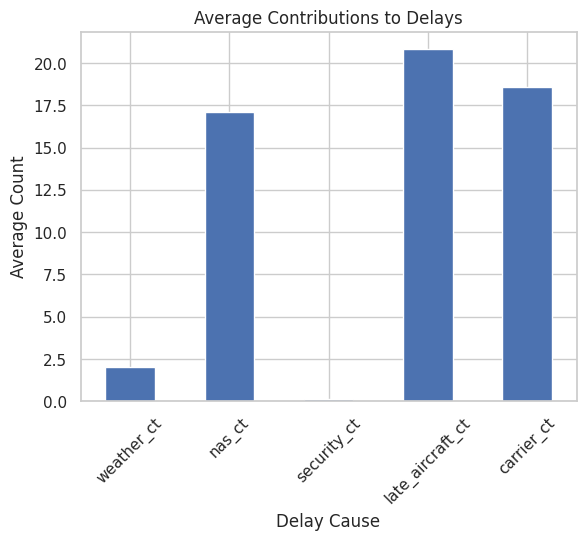

In [42]:
delay_factors = df[['weather_ct', 'nas_ct', 'security_ct', 'late_aircraft_ct', 'carrier_ct']].mean()
delay_factors.plot(kind='bar')
plt.title('Average Contributions to Delays')
plt.xlabel('Delay Cause')
plt.ylabel('Average Count')
plt.xticks(rotation=45)
plt.show()

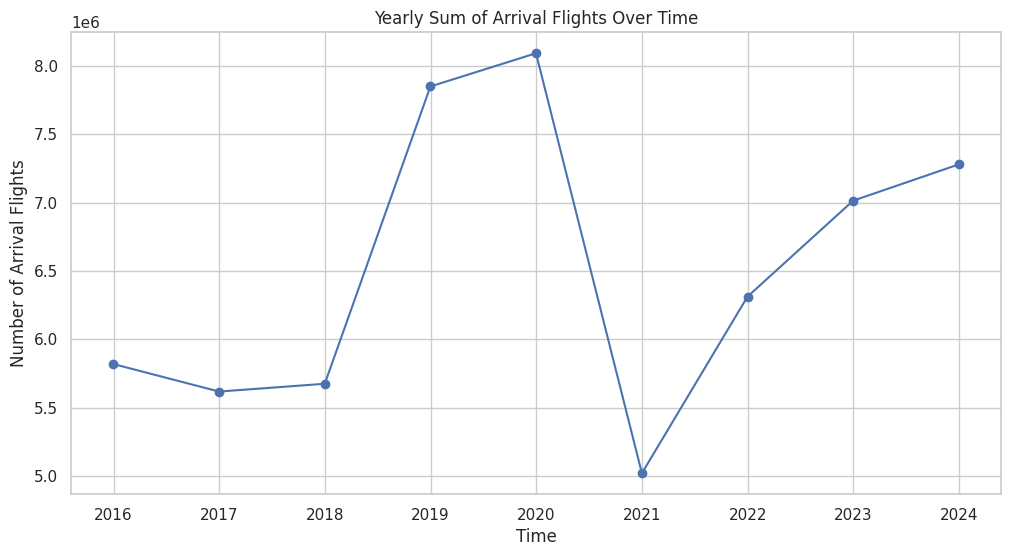

In [43]:
df['date'] = pd.to_datetime(df[['year', 'month']].assign(day=1))  

df.set_index('date', inplace=True)  

yearly_df = df.resample('Y').sum()  

plt.figure(figsize=(12, 6))
plt.plot(yearly_df['arr_flights'], marker='o', linestyle='-')
plt.title('Yearly Sum of Arrival Flights Over Time')
plt.xlabel('Time')
plt.ylabel('Number of Arrival Flights')
plt.show()

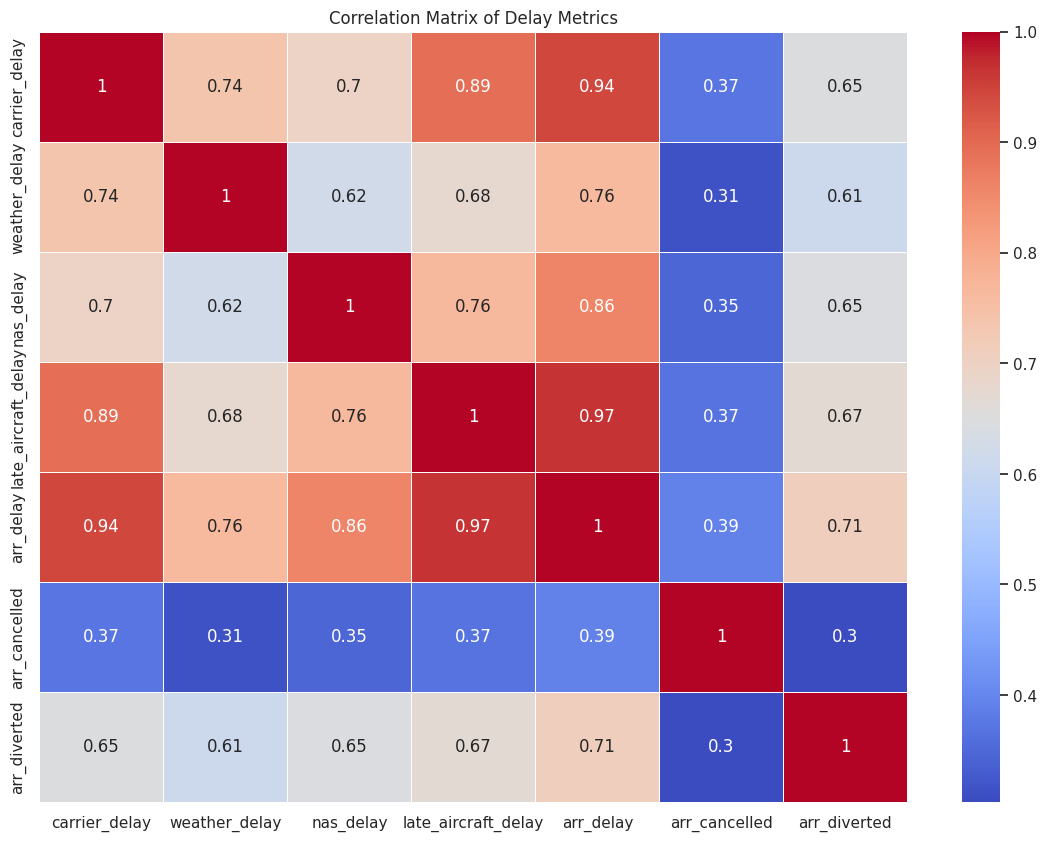

In [44]:
delay_reasons = ['carrier_delay', 'weather_delay', 'nas_delay', 'late_aircraft_delay']
plt.figure(figsize=(14, 10))
corr_matrix = df[delay_reasons + ['arr_delay', 'arr_cancelled', 'arr_diverted']].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Matrix of Delay Metrics')
plt.show()

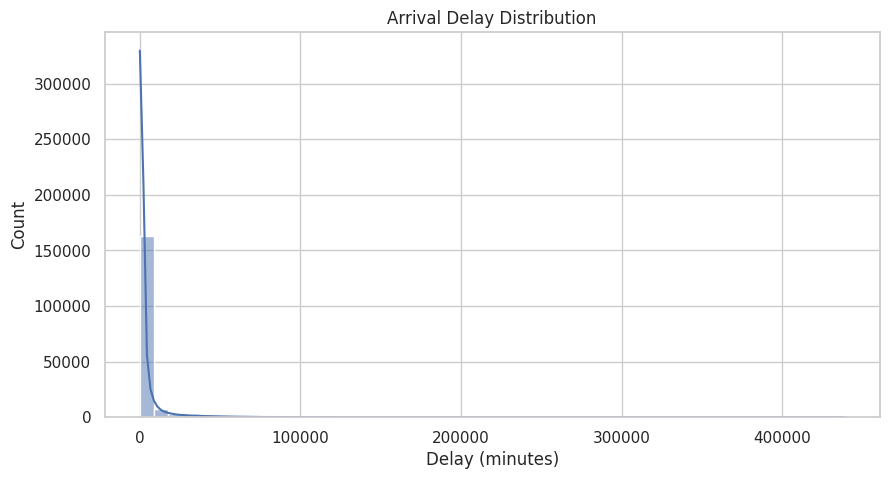

In [45]:
plt.figure(figsize=(10,5))
sns.histplot(df['arr_delay'], bins=50, kde=True)
plt.title('Arrival Delay Distribution')
plt.xlabel('Delay (minutes)')
plt.show()

# Insights of EDA

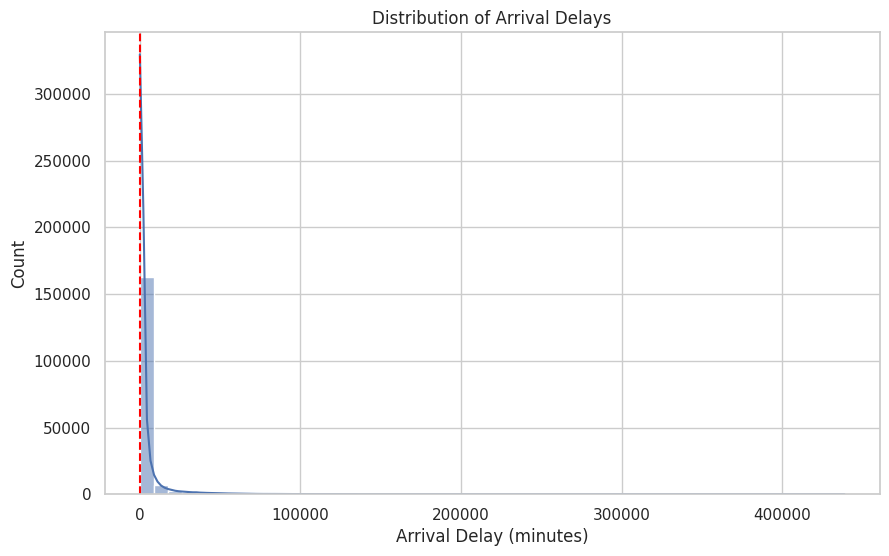

In [46]:
plt.figure(figsize=(10,6))
sns.histplot(df['arr_delay'], bins=50, kde=True)
plt.title("Distribution of Arrival Delays")
plt.xlabel("Arrival Delay (minutes)")
plt.axvline(0, color='red', linestyle='--')
plt.show()

Most flights have minor or no delay (peak near 0)

Long tail: significant number of flights delayed > 100 mins

Early flights have negative delay (early arrival)

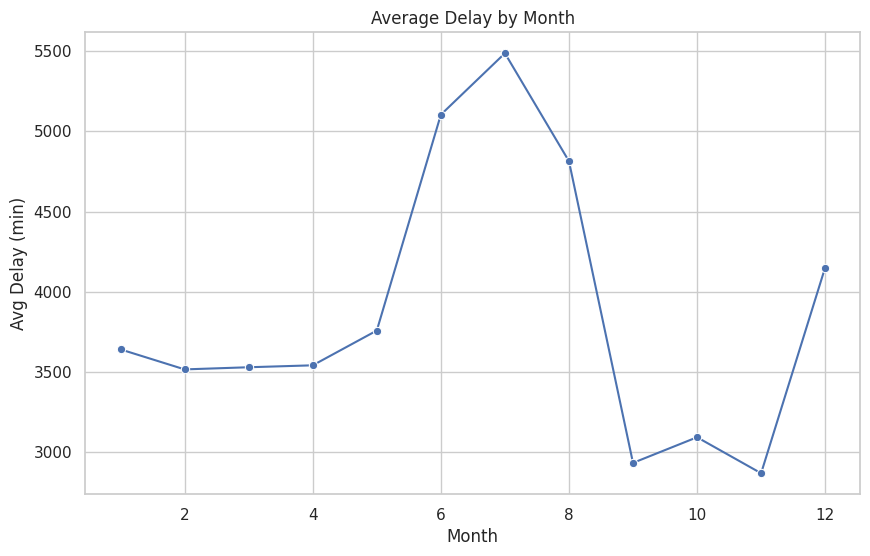

In [47]:
monthly_delay = df.groupby('month')['arr_delay'].mean().reset_index()

plt.figure(figsize=(10,6))
sns.lineplot(data=monthly_delay, x='month', y='arr_delay', marker='o')
plt.title("Average Delay by Month")
plt.xlabel("Month")
plt.ylabel("Avg Delay (min)")
plt.grid(True)
plt.show()

Identify peak delay months (e.g. holiday seasons) -->seasonal delay(rain)

Main delay moth --> June July August

Can recommend schedule buffering in those months

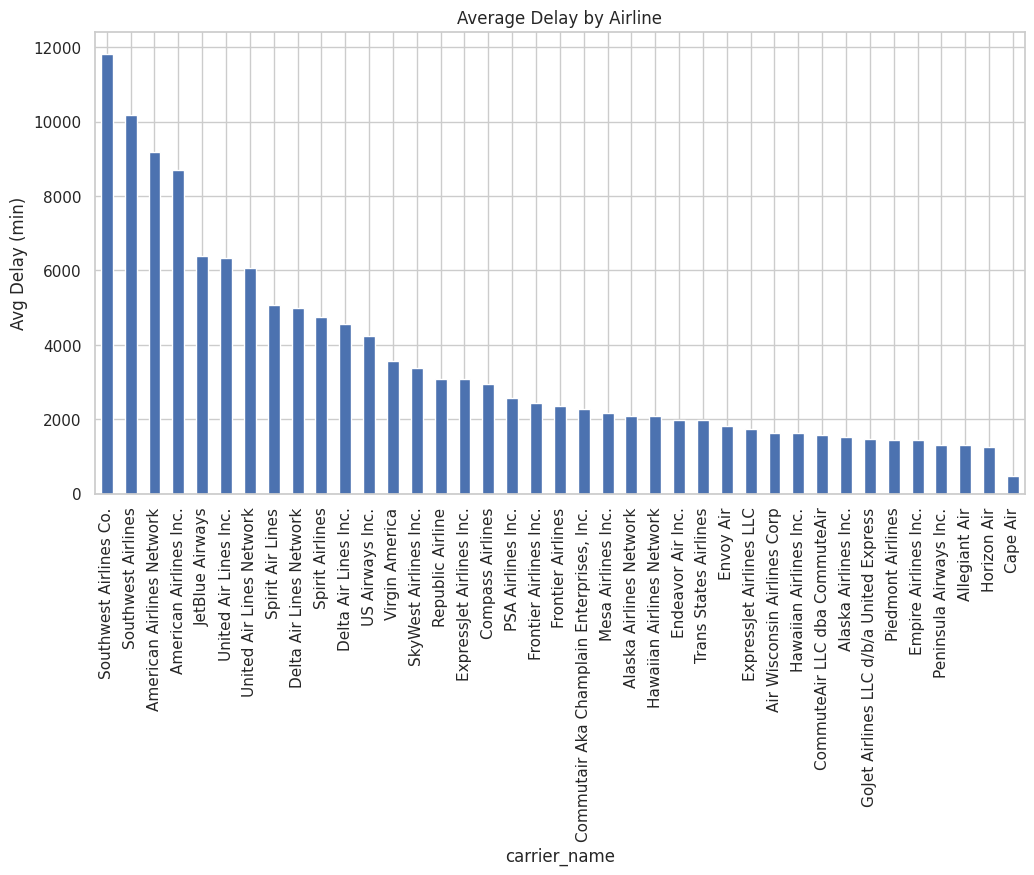

In [48]:
carrier_avg = df.groupby('carrier_name')['arr_delay'].mean().sort_values(ascending=False)

plt.figure(figsize=(12,6))
carrier_avg.plot(kind='bar')
plt.title("Average Delay by Airline")
plt.ylabel("Avg Delay (min)")
plt.xticks(rotation=90)
plt.show()

Specific carriers consistently underperform

Potential for deeper carrier-specific optimization

Delayed Airline-->Southwest Airlines Co.,Southwest Airlines

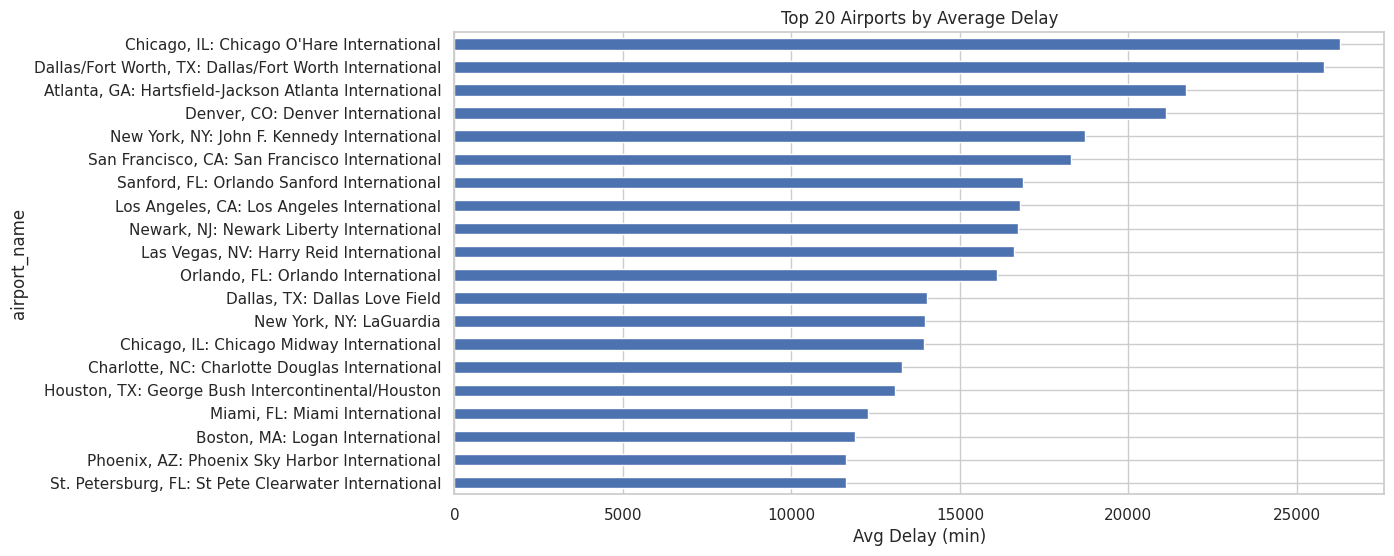

In [49]:
airport_avg = df.groupby('airport_name')['arr_delay'].mean().sort_values(ascending=False).head(20)

plt.figure(figsize=(12,6))
airport_avg.plot(kind='barh')
plt.title("Top 20 Airports by Average Delay")
plt.xlabel("Avg Delay (min)")
plt.gca().invert_yaxis()
plt.show()

Some airports face systemic congestion/delay

Root causes may include runway availability or terminal delays

Top Airport for delay-->Chicago, IL: Chicago O'Hare International
Dallas/Fort Worth, TX: Dallas/Fort Worth International

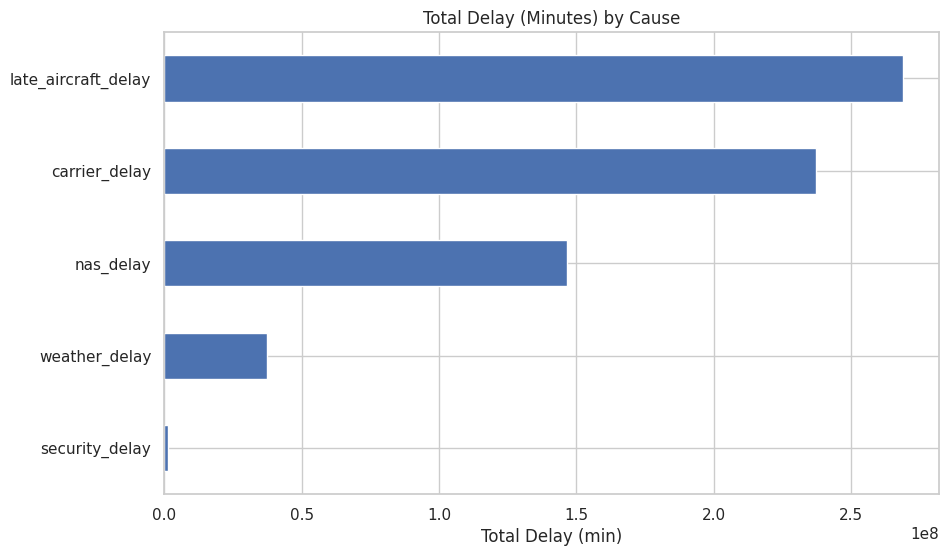

In [50]:
cause_totals = df[['carrier_delay', 'weather_delay', 'nas_delay', 'security_delay', 'late_aircraft_delay']].sum()

plt.figure(figsize=(10,6))
cause_totals.sort_values().plot(kind='barh')
plt.title("Total Delay (Minutes) by Cause")
plt.xlabel("Total Delay (min)")
plt.show()

Most delay minutes are due to:

Late Aircraft

Carrier Delay

These are operationally controllable → key intervention points

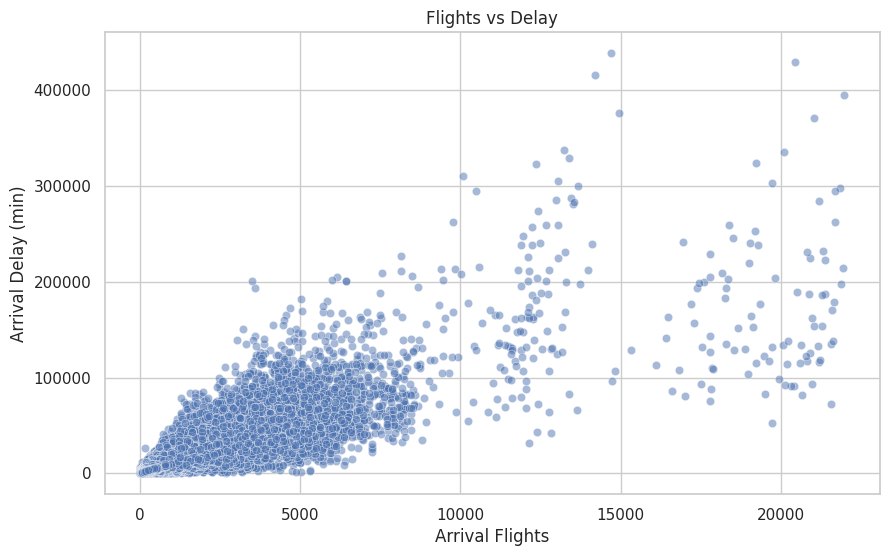

In [51]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='arr_flights', y='arr_delay', alpha=0.5)
plt.title("Flights vs Delay")
plt.xlabel("Arrival Flights")
plt.ylabel("Arrival Delay (min)")
plt.show()

Busy time slots correlate with increased delays

Can be used to suggest decongesting schedules

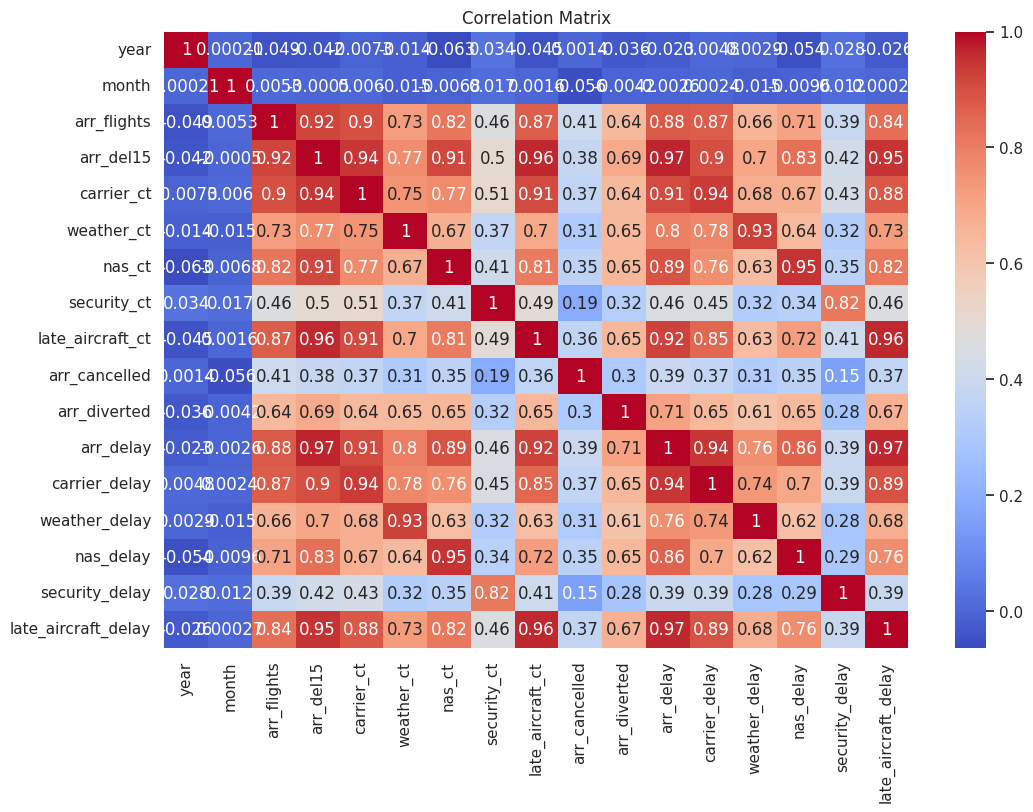

In [52]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

Strong positive correlation:

Between total delay and controllable components

Between arr_del15 and delay durations

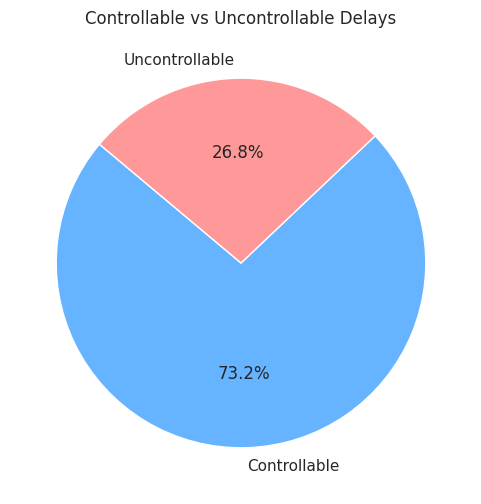

In [53]:
controllable = df['carrier_delay'] + df['late_aircraft_delay']
uncontrollable = df['weather_delay'] + df['nas_delay'] + df['security_delay']

plt.figure(figsize=(6,6))
plt.pie([controllable.sum(), uncontrollable.sum()], labels=['Controllable', 'Uncontrollable'],
        autopct='%1.1f%%', startangle=140, colors=['#66b3ff','#ff9999'])
plt.title("Controllable vs Uncontrollable Delays")
plt.show()

If >60% delays are controllable → focus efforts here
Strengthens case for OAI-weighted modeling

In [1]:
import pandas as pd
import numpy as np

In [6]:
df = pd.read_csv("/kaggle/input/airline-delay/Airline_Delay_Cause.csv")  

In [3]:
df.isnull().sum()

year                     0
month                    0
carrier                  0
carrier_name             0
airport                  0
airport_name             0
arr_flights            341
arr_del15              591
carrier_ct             341
weather_ct             341
nas_ct                 341
security_ct            341
late_aircraft_ct       341
arr_cancelled          341
arr_diverted           341
arr_delay              341
carrier_delay          341
weather_delay          341
nas_delay              341
security_delay         341
late_aircraft_delay    341
dtype: int64

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, roc_curve, auc, classification_report
import shap
from sklearn.preprocessing import LabelEncoder

In [7]:
df.dropna(inplace=True)  # ✅ Drops all rows with at least one NaN value

In [8]:
df.isnull().sum()

year                   0
month                  0
carrier                0
carrier_name           0
airport                0
airport_name           0
arr_flights            0
arr_del15              0
carrier_ct             0
weather_ct             0
nas_ct                 0
security_ct            0
late_aircraft_ct       0
arr_cancelled          0
arr_diverted           0
arr_delay              0
carrier_delay          0
weather_delay          0
nas_delay              0
security_delay         0
late_aircraft_delay    0
dtype: int64

In [7]:
print(df.size) #very big data(can ignore some of missing values)
print(df.shape[0]) #rows
print(df.shape[1]) #cols

3753687
178747
21


In [10]:
df.isnull().sum()

year                   0
month                  0
carrier                0
carrier_name           0
airport                0
airport_name           0
arr_flights            0
arr_del15              0
carrier_ct             0
weather_ct             0
nas_ct                 0
security_ct            0
late_aircraft_ct       0
arr_cancelled          0
arr_diverted           0
arr_delay              0
carrier_delay          0
weather_delay          0
nas_delay              0
security_delay         0
late_aircraft_delay    0
dtype: int64

# **Data Preprocessing**

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, roc_curve, auc, classification_report
import shap

In [12]:
df['delay_rate'] = df['arr_del15'] / df['arr_flights']
df['high_delay'] = (df['delay_rate'] > 0.2).astype(int)  # Binary target: 1 if >20% flights delayed, 0 otherwise

In [13]:
categorical_features = ['carrier', 'airport', 'month']  # Including month as categorical
numerical_features = [
    'arr_flights', 
    'carrier_ct', 'weather_ct', 'nas_ct', 'security_ct', 'late_aircraft_ct',
    'carrier_delay', 'weather_delay', 'nas_delay', 'security_delay', 'late_aircraft_delay'
]

In [14]:
target = 'high_delay'

# **Model Evaluation**

In [15]:

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ])

X = df[categorical_features + numerical_features]
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

model = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(n_estimators=100, random_state=42))
])

In [16]:
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:, 1]

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

In [17]:
print("Flight Delay Classification Model Evaluation:")
print("Target: Predicting if a carrier-airport combination will have >20% of flights delayed by 15+ minutes")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-score: {f1:.4f}")

Flight Delay Classification Model Evaluation:
Target: Predicting if a carrier-airport combination will have >20% of flights delayed by 15+ minutes
Accuracy: 0.9072
Precision: 0.9094
Recall: 0.8288
F1-score: 0.8672



Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.95      0.93     34010
           1       0.91      0.83      0.87     19615

    accuracy                           0.91     53625
   macro avg       0.91      0.89      0.90     53625
weighted avg       0.91      0.91      0.91     53625



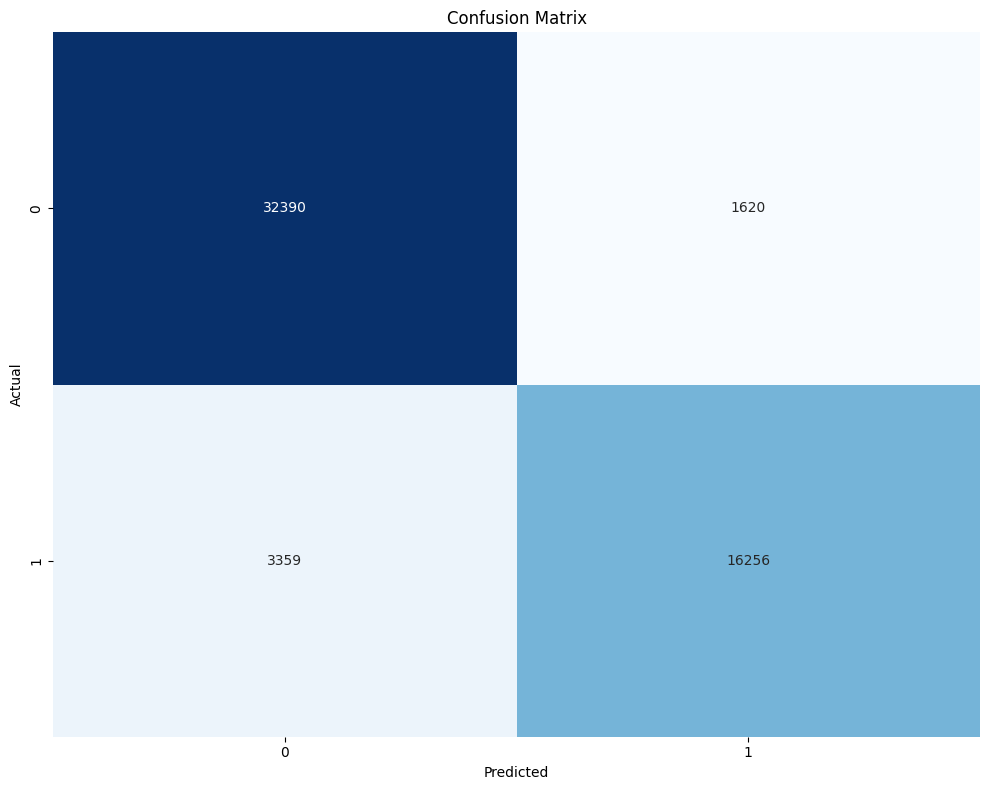

In [18]:
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

plt.figure(figsize=(10, 8))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

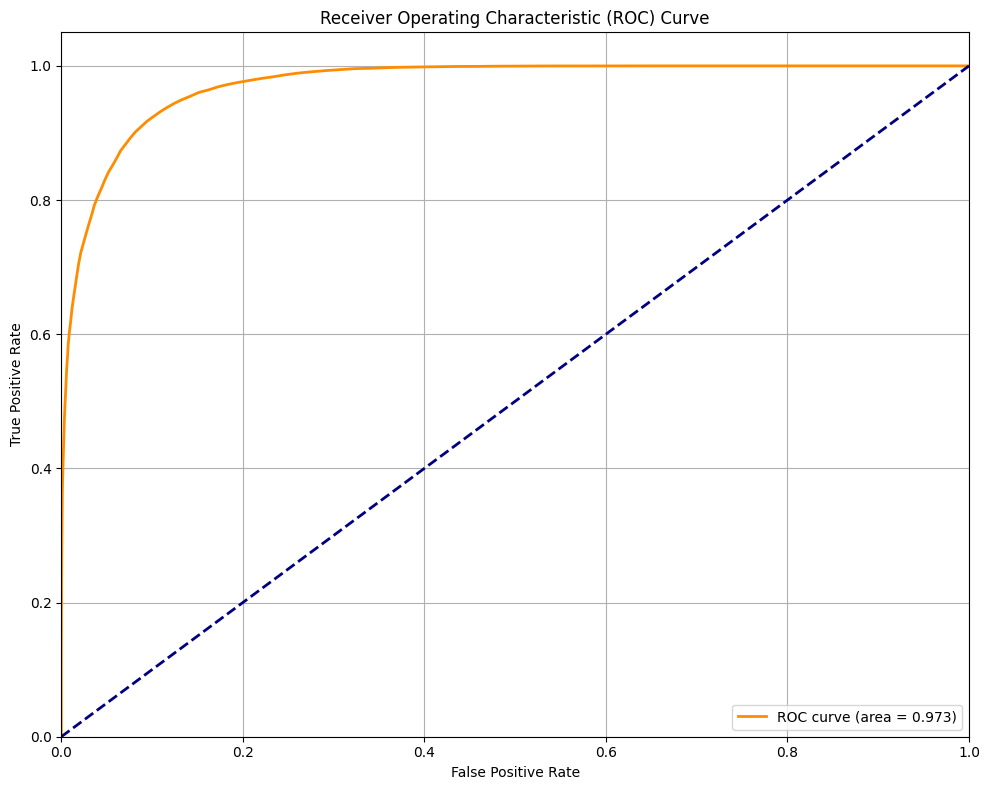

In [19]:
plt.figure(figsize=(10, 8))
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.show()

# Trying using Different Models

In [20]:
models = {
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=42),
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42)
}

cv_results = {}
for name, clf in models.items():
    pipeline = Pipeline([('preprocessor', preprocessor), ('classifier', clf)])
    scores = cross_val_score(pipeline, X, y, cv=5, scoring='f1')
    cv_results[name] = scores
    print(f"{name} - Mean F1: {np.mean(scores):.4f}, Std: {np.std(scores):.4f}")

Random Forest - Mean F1: 0.8510, Std: 0.0077
Gradient Boosting - Mean F1: 0.8883, Std: 0.0041
Logistic Regression - Mean F1: 0.9473, Std: 0.0144


# For Logistic Regression

In [ ]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ])

X = df[categorical_features + numerical_features]
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

model = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(n_estimators=100, random_state=42))
])

In [16]:
model = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000, random_state=42))
])

In [17]:
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:, 1]

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

In [18]:
print("Flight Delay Classification Model Evaluation:")
print("Target: Predicting if a carrier-airport combination will have >20% of flights delayed by 15+ minutes")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-score: {f1:.4f}")

Flight Delay Classification Model Evaluation:
Target: Predicting if a carrier-airport combination will have >20% of flights delayed by 15+ minutes
Accuracy: 0.9632
Precision: 0.9948
Recall: 0.9042
F1-score: 0.9474



Classification Report:
              precision    recall  f1-score   support

           0       0.95      1.00      0.97     34010
           1       0.99      0.90      0.95     19615

    accuracy                           0.96     53625
   macro avg       0.97      0.95      0.96     53625
weighted avg       0.96      0.96      0.96     53625



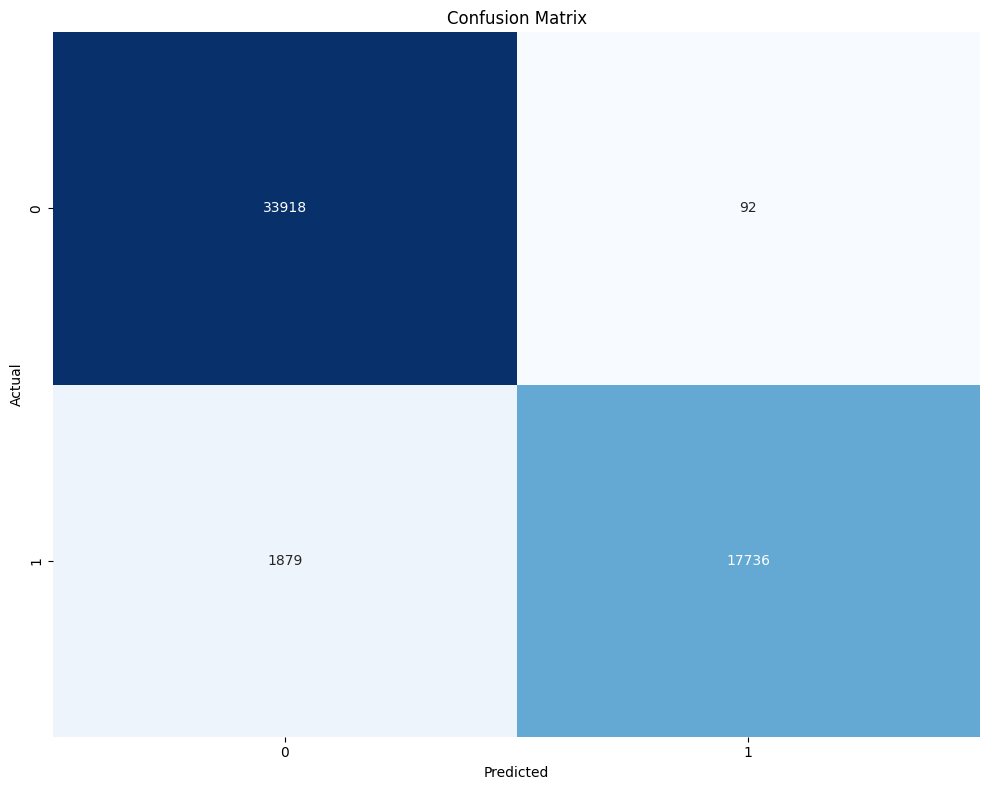

In [24]:
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

plt.figure(figsize=(10, 8))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

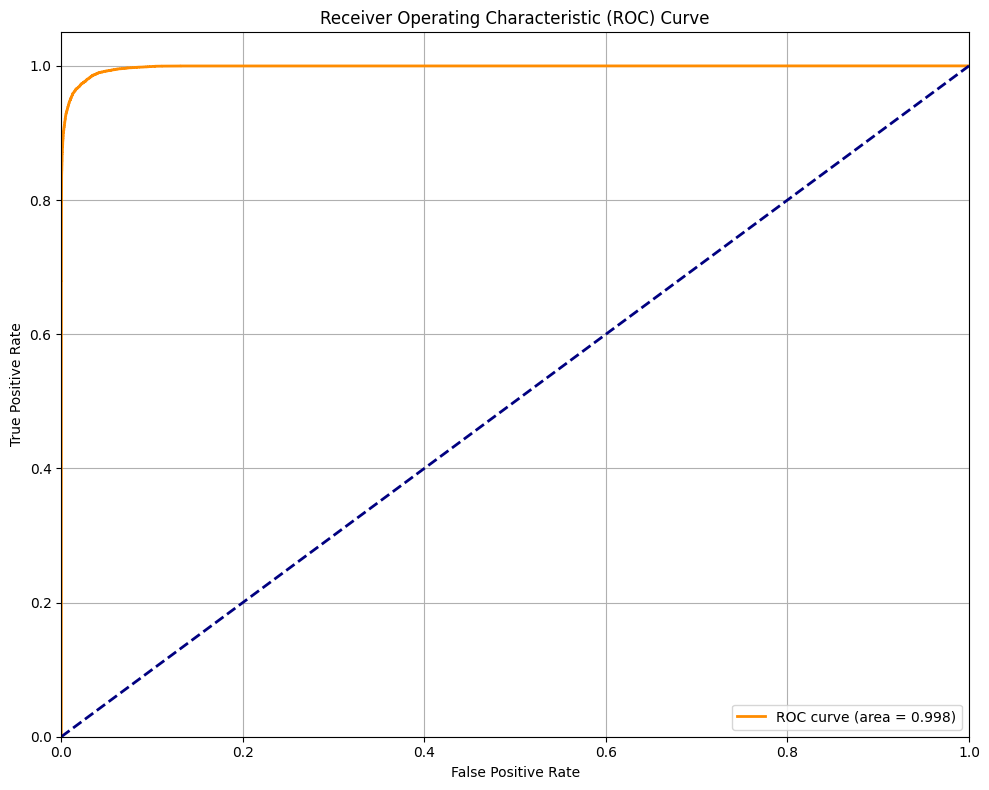

In [25]:
plt.figure(figsize=(10, 8))
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.show()

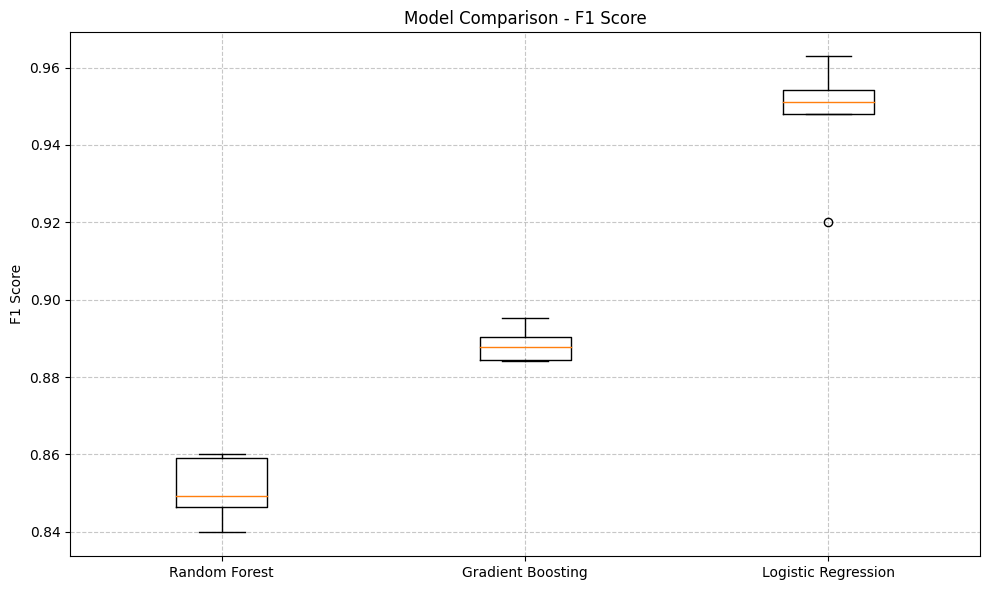

In [26]:

plt.figure(figsize=(10, 6))
plt.boxplot([cv_results[name] for name in models.keys()], labels=models.keys())
plt.title('Model Comparison - F1 Score')
plt.ylabel('F1 Score')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# **Operational Adjustability Index (OAI):**

In [19]:
oai_weights = {
    'carrier_delay': 1.0,        # Airlines have full control over these
    'carrier_ct': 1.0,
    'late_aircraft_delay': 0.8,  # Usually can be managed with better scheduling
    'late_aircraft_ct': 0.8,
    'nas_delay': 0.5,            # Some control, but depends on air traffic control
    'nas_ct': 0.5,
    'security_delay': 0.3,       # Limited control, depends on TSA/security procedures
    'security_ct': 0.3,
    'weather_delay': 0.2,        # Can't control the weather! 
    'weather_ct': 0.2
}

In [20]:
def oai_weighted_score(y_true, y_pred, X, feature_names, weights=oai_weights):
    """
    Custom scoring function that weights errors based on OAI.
    Gives higher penalty when model misclassifies instances with controllable delays.
    """
    instance_weights = np.ones(len(y_true))
    
    for i, row in X.iterrows():
        weight_sum = 1.0  # Base weight
        count = 0
        
        for col in row.index:
            for delay_type, weight in weights.items():
                if delay_type in col and row[col] > 0:
                    weight_sum += weight
                    count += 1
        
        if count > 0:
            weight_sum /= count
            
        instance_weights[i] = weight_sum
    
    errors = (y_true != y_pred).astype(float) * instance_weights
    return -np.mean(errors)  # Negative because we want to maximize score

In [21]:
categorical_features = ['carrier', 'airport', 'month']
numerical_features = [
    'arr_flights', 
    'carrier_ct', 'weather_ct', 'nas_ct', 'security_ct', 'late_aircraft_ct',
    'carrier_delay', 'weather_delay', 'nas_delay', 'security_delay', 'late_aircraft_delay'
]

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ])

X = df[categorical_features + numerical_features]
y = df['high_delay']  # Our binary target variable

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

model = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42))
])

# **Explainable ML using SHAP:**

In [22]:

model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:, 1]

print("Calculating SHAP values - this helps us understand what drives delay predictions...")

Calculating SHAP values - this helps us understand what drives delay predictions...


In [23]:
def get_feature_names(column_transformer):
    """Extract feature names from column transformer components"""
    output_features = []
    
    for name, pipe, features in column_transformer.transformers_:
        if name == 'drop' or pipe == 'drop':
            continue
            
        if name == 'num':
            output_features.extend(features)
        elif name == 'cat':
            for i, feature in enumerate(features):
                cats = pipe.categories_[i]
                output_features.extend([f"{feature}_{c}" for c in cats])
                
    return output_features

try:
    feature_names = get_feature_names(model.named_steps['preprocessor'])
except:
    feature_names = numerical_features + [f"encoded_{i}" for i in range(50)]  # Approximate

In [24]:


X_sample = X_test.iloc[:300]  # Using first 300 test instances for SHAP analysis

X_sample_transformed = model.named_steps['preprocessor'].transform(X_sample)

if hasattr(X_sample_transformed, "toarray"):
    X_sample_transformed = X_sample_transformed.toarray()

explainer = shap.KernelExplainer(
    model.named_steps['classifier'].predict_proba, 
    X_sample_transformed
)

shap_values = explainer.shap_values(X_sample_transformed)

if isinstance(shap_values, list):
    shap_values = shap_values[1]

  0%|          | 0/300 [00:00<?, ?it/s]

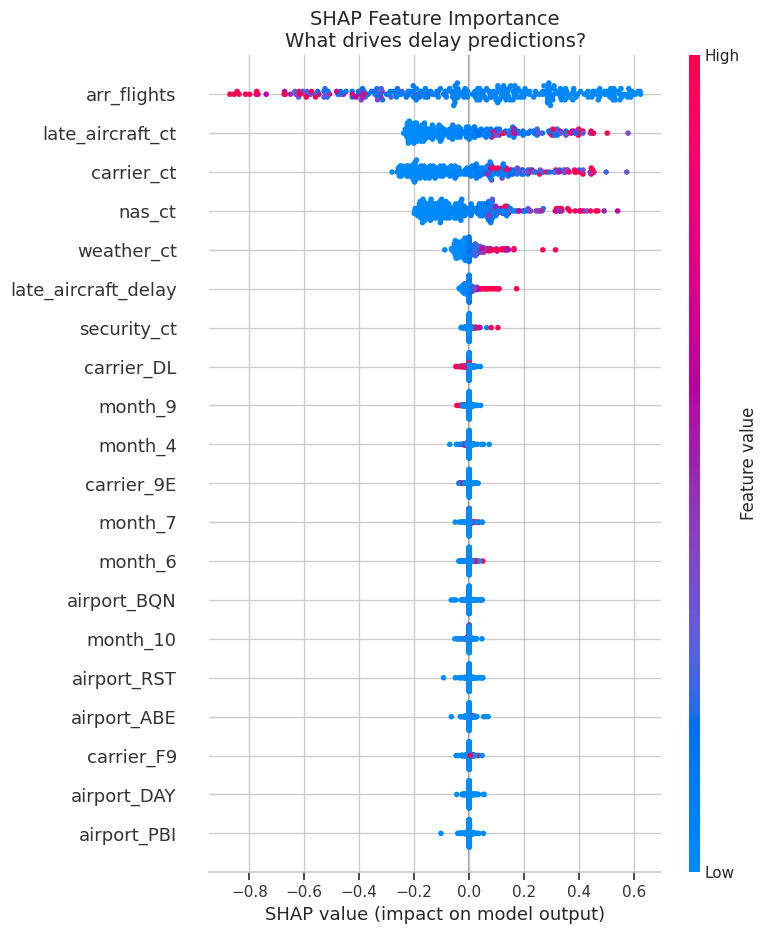

In [25]:
plt.figure(figsize=(14, 10))
shap.summary_plot(
    shap_values, 
    X_sample_transformed,
    feature_names=feature_names[:X_sample_transformed.shape[1]],
    show=False
)
plt.title('SHAP Feature Importance\nWhat drives delay predictions?', fontsize=14)
plt.tight_layout()
plt.show()

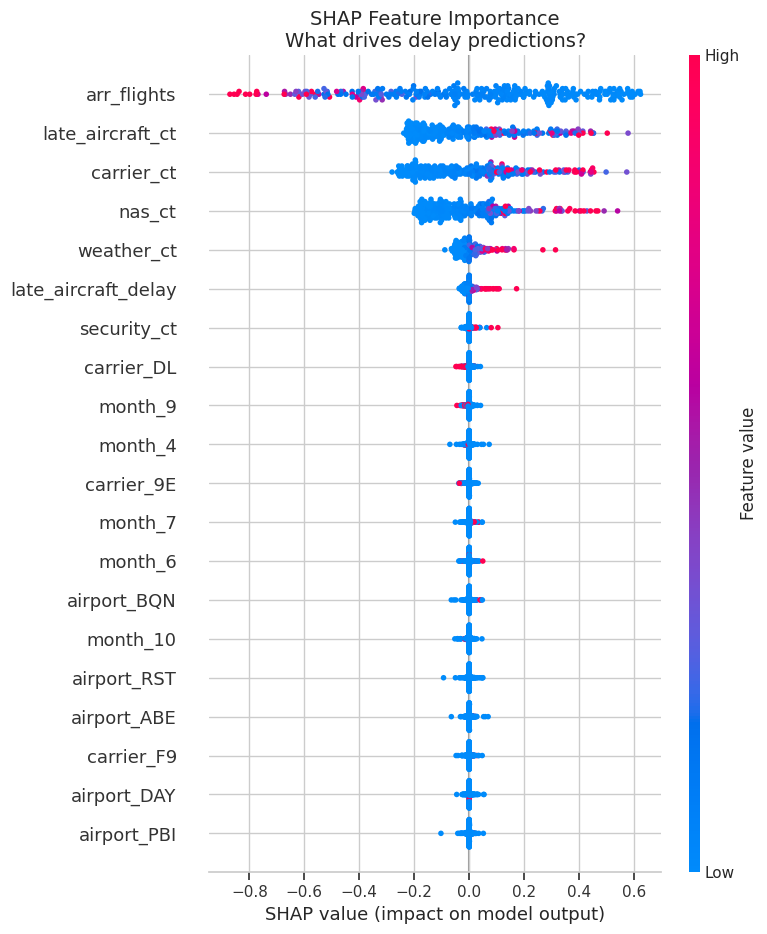

Applying OAI weights to SHAP values to highlight controllable factors...


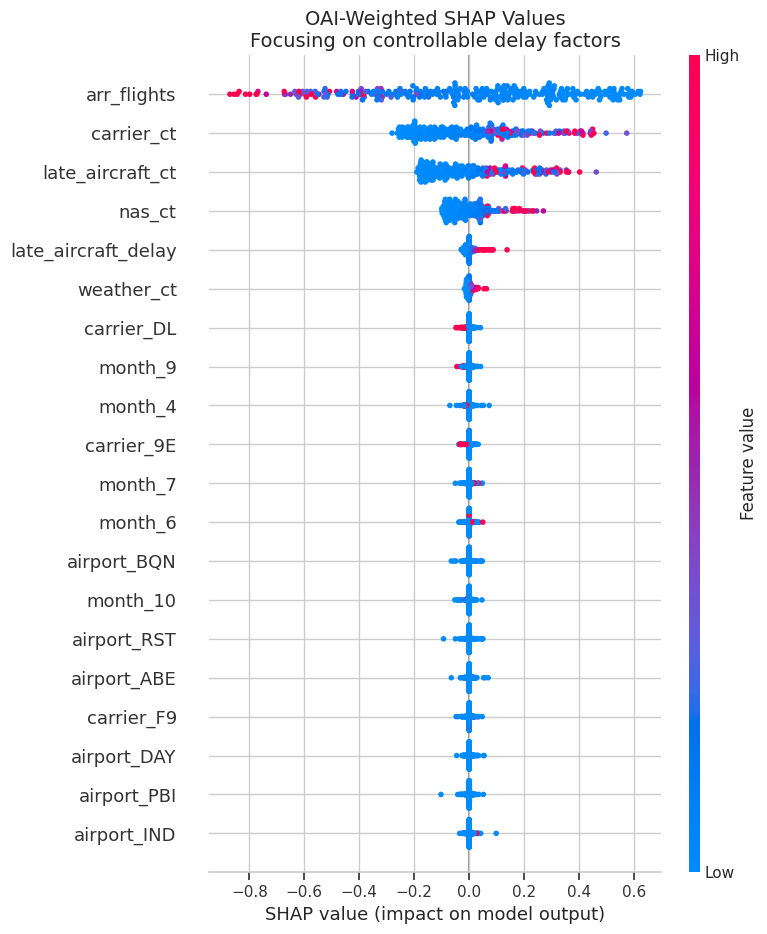

In [26]:
plt.figure(figsize=(14, 10))
shap.summary_plot(
    shap_values, 
    X_sample_transformed,
    feature_names=feature_names[:X_sample_transformed.shape[1]],
    show=False
)
plt.title('SHAP Feature Importance\nWhat drives delay predictions?', fontsize=14)
plt.tight_layout()
plt.show()

print("Applying OAI weights to SHAP values to highlight controllable factors...")

oai_shap_values = shap_values.copy()

for i, feature in enumerate(feature_names[:X_sample_transformed.shape[1]]):
    for delay_type, weight in oai_weights.items():
        if delay_type in feature:
            oai_shap_values[:, i] *= weight
            break

plt.figure(figsize=(14, 10))
shap.summary_plot(
    oai_shap_values, 
    X_sample_transformed,
    feature_names=feature_names[:X_sample_transformed.shape[1]],
    show=False
)
plt.title('OAI-Weighted SHAP Values\nFocusing on controllable delay factors', fontsize=14)
plt.tight_layout()
plt.show()

In [27]:
controllability_scores = []

for i in range(len(shap_values)):
    controllable_impact = 0
    total_impact = 0
    
    for j, feature in enumerate(feature_names[:X_sample_transformed.shape[1]]):
        impact = abs(shap_values[i, j])
        total_impact += impact
        
        for delay_type, weight in oai_weights.items():
            if delay_type in feature:
                controllable_impact += impact * weight
                break
    
    if total_impact > 0:
        controllability = controllable_impact / total_impact
    else:
        controllability = 0
        
    controllability_scores.append(controllability)

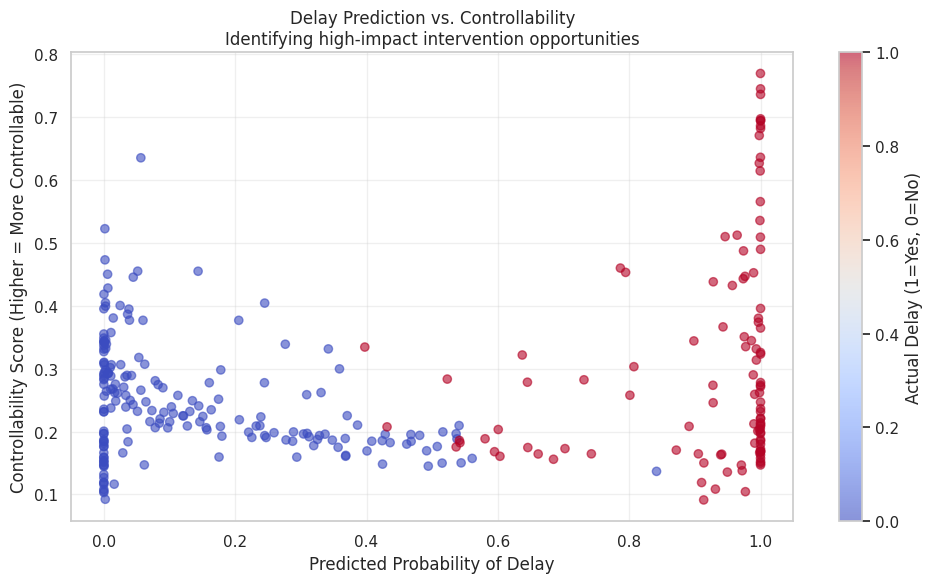

In [28]:
sample_results = X_sample.copy()
sample_results['actual_delay'] = y_test.iloc[:300].values
sample_results['predicted_delay'] = y_pred[:300]
sample_results['delay_probability'] = y_pred_proba[:300]
sample_results['controllability'] = controllability_scores

plt.figure(figsize=(10, 6))
plt.scatter(
    sample_results['delay_probability'], 
    sample_results['controllability'],
    alpha=0.6, 
    c=sample_results['actual_delay'], 
    cmap='coolwarm'
)
plt.colorbar(label='Actual Delay (1=Yes, 0=No)')
plt.xlabel('Predicted Probability of Delay')
plt.ylabel('Controllability Score (Higher = More Controllable)')
plt.title('Delay Prediction vs. Controllability\nIdentifying high-impact intervention opportunities')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [29]:
def get_action_category(prob, control):
    if prob > 0.7 and control > 0.6:
        return "High Priority Action"  # High delay risk, highly controllable
    elif prob > 0.7 and control <= 0.6:
        return "Monitor External Factors"  # High delay risk, less controllable
    elif prob <= 0.7 and control > 0.6:
        return "Preventative Measures"  # Lower delay risk, but controllable
    else:
        return "Low Concern"  # Lower delay risk, less controllable

sample_results['action_category'] = sample_results.apply(
    lambda x: get_action_category(x['delay_probability'], x['controllability']), 
    axis=1
)


Actionable Insights by Category:
                          delay_probability  controllability  count
action_category                                                    
High Priority Action               0.999590         0.687099     12
Low Concern                        0.165572         0.242377    205
Monitor External Factors           0.958130         0.267821     82
Preventative Measures              0.056357         0.634729      1


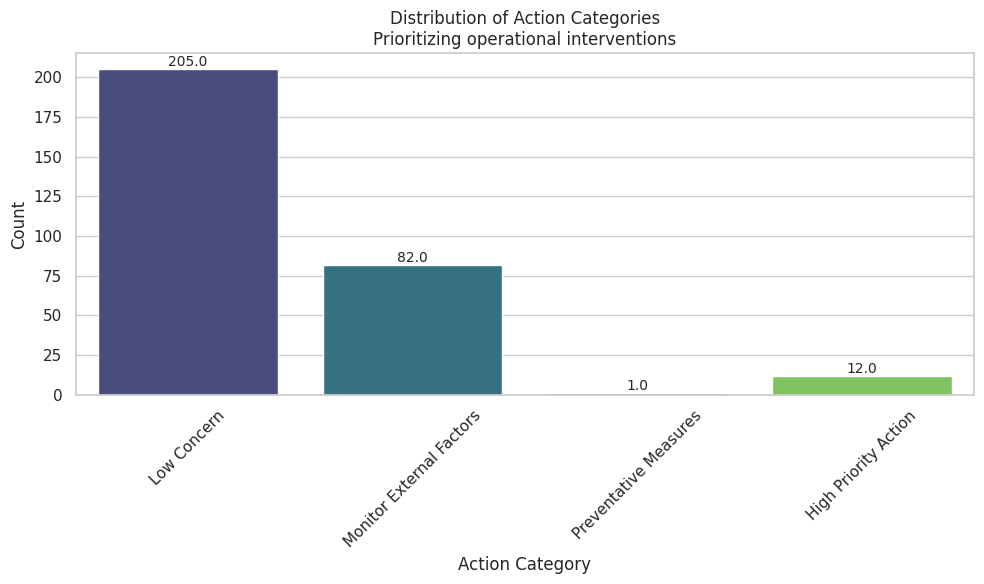

In [30]:
action_summary = sample_results.groupby('action_category').agg({
    'delay_probability': 'mean',
    'controllability': 'mean',
    'action_category': 'count'
}).rename(columns={'action_category': 'count'})

print("\nActionable Insights by Category:")
print(action_summary)

plt.figure(figsize=(10, 6))
ax = sns.countplot(x='action_category', data=sample_results, palette='viridis')
plt.title('Distribution of Action Categories\nPrioritizing operational interventions')
plt.xlabel('Action Category')
plt.ylabel('Count')
plt.xticks(rotation=45)
for p in ax.patches:
    ax.annotate(f'{p.get_height()}', (p.get_x() + p.get_width()/2., p.get_height()),
                ha='center', va='bottom', fontsize=10)
plt.tight_layout()
plt.show()

In [31]:
if "High Priority Action" in sample_results['action_category'].values:
    high_priority = sample_results[sample_results['action_category'] == "High Priority Action"].head(5)
    
    print("\nExample High Priority Cases (Where we can make the biggest impact):")
    for idx, row in high_priority.iterrows():
        print(f"\nCase {idx}:")
        print(f"  Carrier: {row['carrier']}, Airport: {row['airport']}, Month: {row['month']}")
        print(f"  Predicted delay probability: {row['delay_probability']:.2f}")
        print(f"  Controllability score: {row['controllability']:.2f}")
        
        instance_idx = X_sample.index.get_loc(idx)
        instance_shap = shap_values[instance_idx]
        
        feature_imp = [(feature_names[i], instance_shap[i], 
                       any(delay in feature_names[i] for delay in oai_weights.keys()))
                      for i in range(len(instance_shap))]
        
        feature_imp.sort(key=lambda x: abs(x[1]), reverse=True)
        controllable_factors = [f for f in feature_imp if f[2]][:3]
        
        print("  Top controllable factors:")
        for feature, impact, _ in controllable_factors:
            impact_type = "increasing" if impact > 0 else "decreasing"
            print(f"    - {feature}: {impact:.4f} ({impact_type} delay risk)")


Example High Priority Cases (Where we can make the biggest impact):

Case 16745:
  Carrier: YV, Airport: MCI, Month: 4
  Predicted delay probability: 1.00
  Controllability score: 0.74
  Top controllable factors:
    - late_aircraft_ct: 0.3166 (increasing delay risk)
    - carrier_ct: 0.1510 (increasing delay risk)
    - late_aircraft_delay: 0.0269 (increasing delay risk)

Case 56591:
  Carrier: WN, Airport: BUF, Month: 7
  Predicted delay probability: 1.00
  Controllability score: 0.70
  Top controllable factors:
    - carrier_ct: 0.4439 (increasing delay risk)
    - late_aircraft_ct: 0.1701 (increasing delay risk)
    - nas_ct: 0.0716 (increasing delay risk)

Case 150439:
  Carrier: VX, Airport: SAN, Month: 4
  Predicted delay probability: 1.00
  Controllability score: 0.74
  Top controllable factors:
    - late_aircraft_ct: 0.5781 (increasing delay risk)
    - carrier_ct: -0.0881 (decreasing delay risk)
    - nas_ct: 0.0495 (increasing delay risk)

Case 60492:
  Carrier: OO, Airpor